In [1]:
import pandas as pd
campaign = pd.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank.csv')

# import polars as pl
# campaign = pl.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank.csv', schema_overrides={'nr.employed': pl.Float64})

In [16]:
campaign

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37064,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes,1
37065,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no,0
37066,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no,0
37067,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes,1


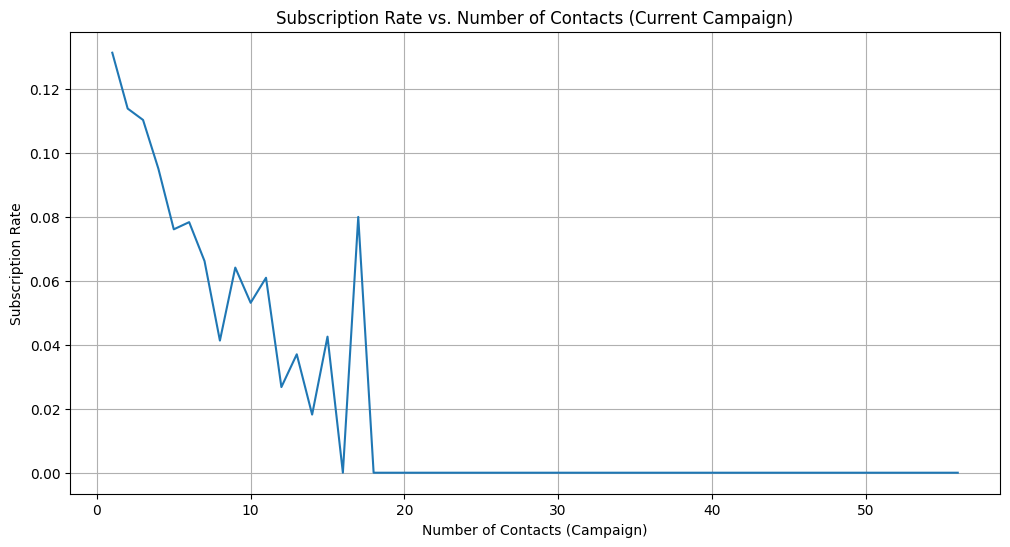

Subscription Rate by Number of Contacts (Current Campaign):
   campaign  subscribed
0         1    0.131347
1         2    0.113879
2         3    0.110325
3         4    0.095038
4         5    0.076117
5         6    0.078363
6         7    0.066190
7         8    0.041322
8         9    0.064151
9        10    0.053140


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'y' column to numerical (1 for 'yes', 0 for 'no')
campaign['subscribed'] = campaign['y'].apply(lambda x: 1 if x == 'yes' else 0)

# Calculate subscription rate by number of contacts
subscription_rate = campaign.groupby('campaign')['subscribed'].mean().reset_index()

# Plot the relationship
plt.figure(figsize=(12, 6))
sns.lineplot(x='campaign', y='subscribed', data=subscription_rate)
plt.title('Subscription Rate vs. Number of Contacts (Current Campaign)')
plt.xlabel('Number of Contacts (Campaign)')
plt.ylabel('Subscription Rate')
plt.grid(True)
plt.show()

print("Subscription Rate by Number of Contacts (Current Campaign):")
print(subscription_rate.head(10))

In [20]:
import altair as alt

# Calculate subscription rate by number of previous contacts
subscription_rate_previous = campaign.groupby('previous')['subscribed'].mean().reset_index()

# Create an Altair chart
chart = alt.Chart(subscription_rate_previous).mark_line().encode(
    x=alt.X('previous:Q', title='Number of Previous Contacts'),
    y=alt.Y('subscribed:Q', title='Subscription Rate'),
    tooltip=['previous', alt.Tooltip('subscribed', format='.2%')]
).properties(
    title='Subscription Rate vs. Number of Previous Contacts'
)

chart

alt.Chart(...)

### Explanation of the Altair Chart:

This Altair chart visualizes the relationship between the number of previous contacts (`previous`) and the subscription rate (`subscribed`).

*   **`import altair as alt`**: Imports the Altair library.
*   **`subscription_rate_previous = campaign.groupby('previous')['subscribed'].mean().reset_index()`**: This line calculates the mean `subscribed` rate for each unique value in the `previous` column, creating a new DataFrame for plotting.
*   **`alt.Chart(subscription_rate_previous)`**: Initializes the chart with the prepared DataFrame.
*   **`.mark_line()`**: Specifies that the chart should be a line plot.
*   **`.encode(...)`**: Defines how data columns are mapped to visual properties:
    *   **`x=alt.X('previous:Q', title='Number of Previous Contacts')`**: Maps the `previous` column to the x-axis. `:Q` specifies a quantitative data type.
    *   **`y=alt.Y('subscribed:Q', title='Subscription Rate')`**: Maps the `subscribed` column to the y-axis, also as a quantitative type.
    *   **`tooltip=['previous', alt.Tooltip('subscribed', format='.2%')]`**: Adds interactive tooltips that show the exact number of previous contacts and the subscription rate (formatted as a percentage) when you hover over the data points.
*   **`.properties(title='...')`**: Sets the title of the chart.
*   **`.interactive()`**: Makes the chart interactive, allowing for zooming and panning.